Simple hierarchical 2PL-esque item-response-theory model.

See [Stan docs](https://mc-stan.org/docs/stan-users-guide/regression.html#item-response-models.section) for a nice description. For the sake of identifiability, this model assumes a fixed (non-hierarchical) prior over `theta`.

In [78]:
import pangolin
from pangolin import interface as pi
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [79]:
# params
num_students = 50
num_items    = 30
num_obs      = 10 * num_students

In [80]:
# random observation pattern
students = np.random.randint(0, num_students, num_obs) # which student in each observation
items    = np.random.randint(0, num_items, num_obs)    # which item in each observation

In [81]:
# model definition

# person ability
theta         = pi.vmap(pi.normal, None, num_students)(0.0, 1.0)

# item difficulty (non-centered)
mean_items    = pi.normal(0, 5)
std_items     = pi.exponential(1.0)
beta_raw      = pi.vmap(pi.normal, None, num_items)(0.0, 1.0)
beta          = mean_items + (beta_raw * std_items)

# item discrimination (non-centered)
mean_log_alpha = pi.normal(0, 0.5)
std_log_alpha  = pi.exponential(1.0)
log_alpha_raw  = pi.vmap(pi.normal, None, num_items)(0.0, 1.0)
log_alpha      = mean_log_alpha + (log_alpha_raw * std_log_alpha)

# likelihood
scores        = pi.exp(log_alpha)[items] * (theta[students] - beta[items])
y             = pi.vmap(pi.bernoulli_logit)(scores)


In [82]:
# group latent variables for convenience
z = dict(theta=theta, beta=beta, log_alpha=log_alpha)

In [83]:
# generate synthetic data and secret true params
[y_obs, z_true] = pangolin.jax_backend.ancestor_sample([y, z])

In [84]:
# do inference
z_samps = pangolin.blackjax.sample(z, y, y_obs, niter=10000)

We now have a standard python dictionary of samples stored in normal numpy arrays.

In [85]:
# print shapes
for item in z_samps:
    print(item, z_samps[item].shape)

beta (10000, 30)
log_alpha (10000, 30)
theta (10000, 50)


Everything below this is plotting code that doesn't use pangolin at all.

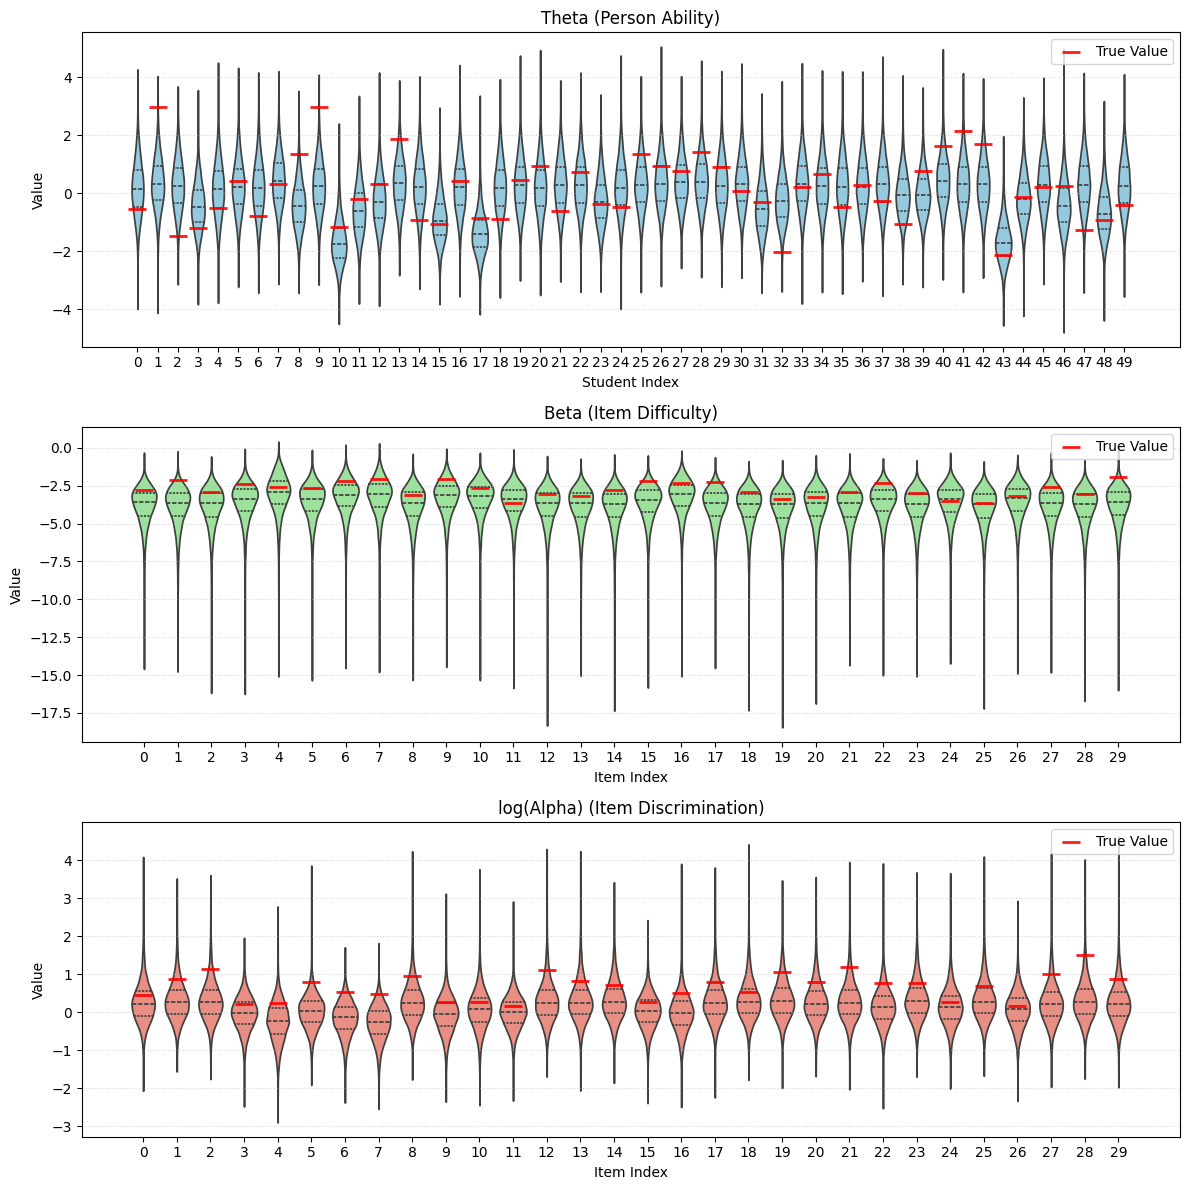

In [86]:
def plot_irt_recovery_violins(z_samps, z_true):
    # Determine which parameters to plot
    params_to_plot = [p for p in ['theta', 'beta', 'log_alpha'] if p in z_samps]
    num_params = len(params_to_plot)

    fig, axes = plt.subplots(num_params, 1, figsize=(12, 4 * num_params))

    # Ensure axes is a list even if only 1 plot
    if num_params == 1:
        axes = [axes]

    # Color palette for the three parameters
    colors = {'theta': 'skyblue', 'beta': 'lightgreen', 'log_alpha': 'salmon'}
    titles = {'theta': 'Theta (Person Ability)', 
              'beta': 'Beta (Item Difficulty)', 
              'log_alpha': 'log(Alpha) (Item Discrimination)'}

    for i, param in enumerate(params_to_plot):
        samps = z_samps[param]
        num_elements = samps.shape[1]

        # Plot Violins
        sns.violinplot(data=samps, ax=axes[i], color=colors[param], inner="quartile")

        # Plot True Values
        axes[i].scatter(range(num_elements), z_true[param], 
                       color='red', marker='_', s=150, linewidth=2, 
                       label='True Value', alpha=0.9, zorder=5)

        axes[i].set_title(titles[param])
        axes[i].set_xlabel(f"{'Student' if param == 'theta' else 'Item'} Index")
        axes[i].set_ylabel("Value")
        axes[i].legend(loc='upper right')
        axes[i].grid(axis='y', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_irt_recovery_violins(z_samps, z_true)

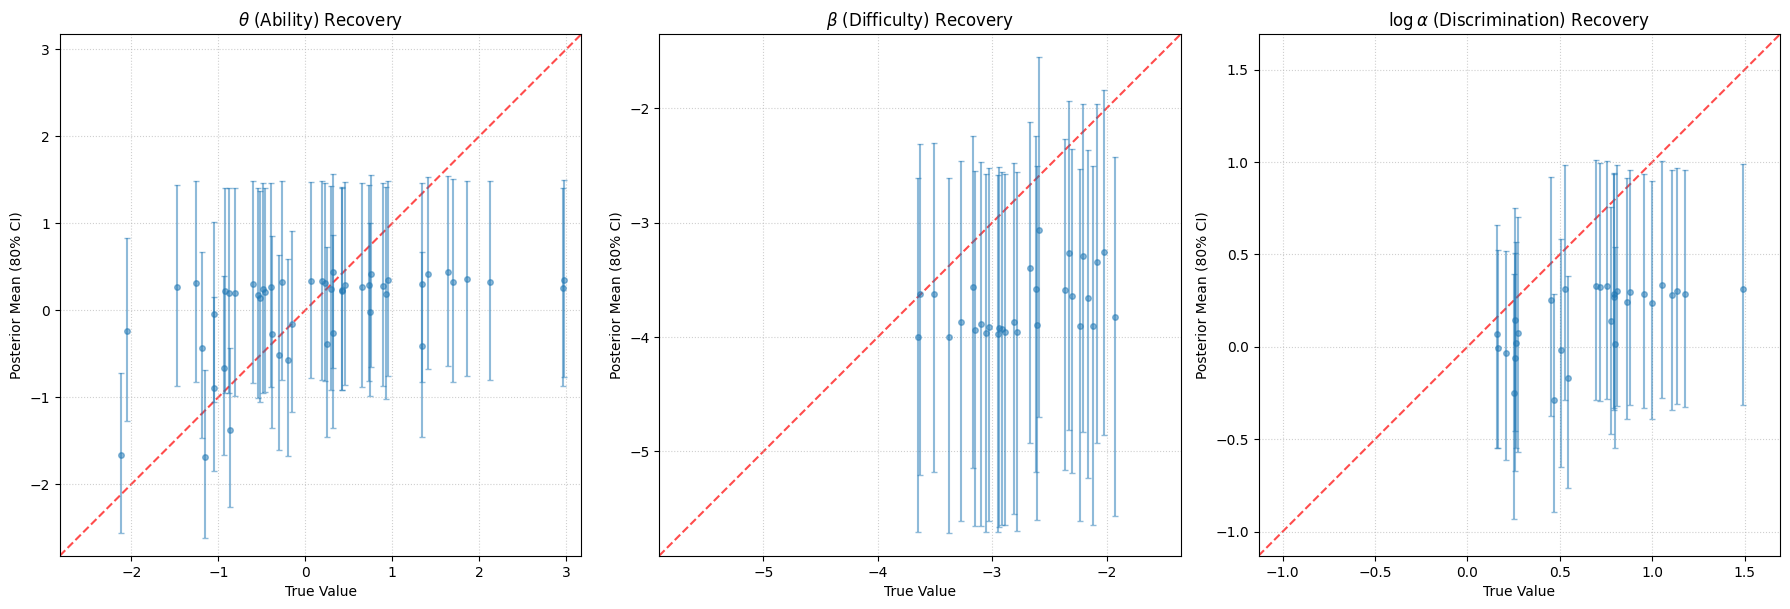

In [87]:
def plot_recovery_scatter(z_samps, z_true):
    # Dynamically determine which parameters to plot based on what's in the dictionary
    params_to_plot = [p for p in ['theta', 'beta', 'log_alpha'] if p in z_samps]
    num_params = len(params_to_plot)

    fig, axes = plt.subplots(1, num_params, figsize=(6 * num_params, 6))

    # Ensure axes is always an array even if only 1 plot
    if num_params == 1:
        axes = [axes]

    for i, param in enumerate(params_to_plot):
        # Calculate posterior mean and 80% Credible Interval
        post_mean = np.mean(z_samps[param], axis=0)
        lower = np.percentile(z_samps[param], 10, axis=0)
        upper = np.percentile(z_samps[param], 90, axis=0)
        true_val = z_true[param]

        # Scatter plot with error bars
        axes[i].errorbar(true_val, post_mean, 
                         yerr=[post_mean - lower, upper - post_mean],
                         fmt='o', alpha=0.5, capsize=2, markersize=4)

        # Calculate absolute limits to keep the plot square
        all_vals = np.concatenate([true_val, lower, upper])
        min_lim, max_lim = all_vals.min() - 0.2, all_vals.max() + 0.2

        # Apply limits to both axes
        axes[i].set_xlim(min_lim, max_lim)
        axes[i].set_ylim(min_lim, max_lim)

        # Force the plot to be physically square
        axes[i].set_aspect('equal', adjustable='box')

        # Identity line (Perfect recovery)
        axes[i].plot([min_lim, max_lim], [min_lim, max_lim], 
                     color='red', linestyle='--', alpha=0.7, zorder=0)

        # Formatting
        title_map = {'theta': r'$\theta$ (Ability)', 
                     'beta': r"$\beta$ (Difficulty)", 
                     'log_alpha': r"$\log \alpha$ (Discrimination)"}

        axes[i].set_title(title_map.get(param, param.capitalize()) + " Recovery")
        axes[i].set_xlabel("True Value")
        axes[i].set_ylabel("Posterior Mean (80% CI)")
        axes[i].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_recovery_scatter(z_samps, z_true)

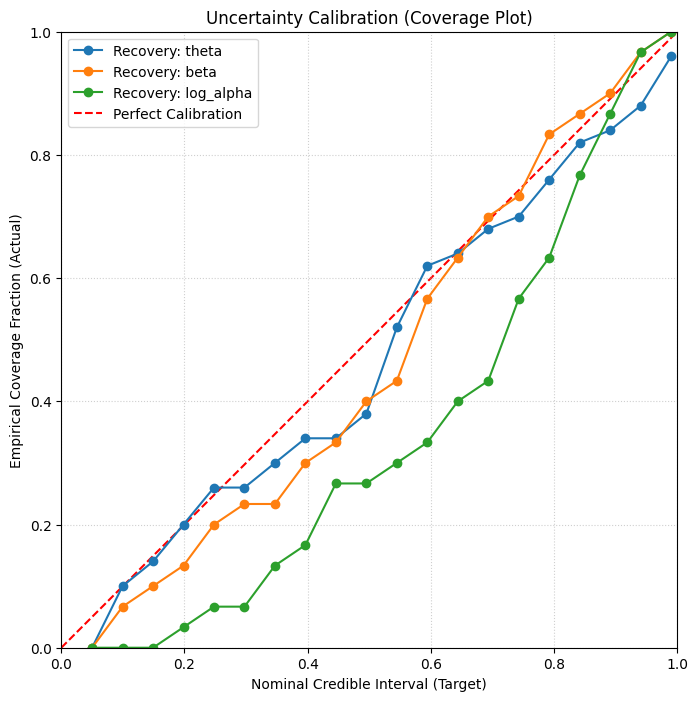

In [88]:
def plot_coverage_calibration(z_samps, z_true):
    # Define the range of credible intervals to check (from 5% to 99%)
    intervals = np.linspace(0.05, 0.99, 20)

    fig, ax = plt.subplots(figsize=(8, 8))

    # Dynamically check for theta, beta, and alpha
    params_to_check = [p for p in ['theta', 'beta', 'log_alpha'] if p in z_samps]

    for param in params_to_check:
        samps = z_samps[param]  # Shape: (num_samples, num_elements)
        true_vals = z_true[param]
        coverage_fractions = []

        for ci in intervals:
            # Calculate lower and upper percentiles for the given CI
            # e.g., for ci=0.90, we want the 5th and 95th percentiles
            lower_p = (1 - ci) / 2 * 100
            upper_p = (1 + ci) / 2 * 100

            lower_bound = np.percentile(samps, lower_p, axis=0)
            upper_bound = np.percentile(samps, upper_p, axis=0)

            # Check if true value is within the bounds
            is_inside = (true_vals >= lower_bound) & (true_vals <= upper_bound)
            coverage_fractions.append(np.mean(is_inside))

        ax.plot(intervals, coverage_fractions, marker='o', label=f'Recovery: {param}')

    # Identity line: Perfect calibration
    ax.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect Calibration', zorder=0)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_xlabel("Nominal Credible Interval (Target)")
    ax.set_ylabel("Empirical Coverage Fraction (Actual)")
    ax.set_title("Uncertainty Calibration (Coverage Plot)")
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.show()

plot_coverage_calibration(z_samps, z_true)